In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Get CIFAR10 by using PyTorch 
import torch
from torchvision import datasets, transforms

# Batch size
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.ToTensor(),
])
# Get training data
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform,
)

# Get test data
test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform,
)

# create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,          # dataset
    batch_size=BATCH_SIZE,  # Specify batch size
    shuffle=True,           # Shuffle
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# CIFAR10 contained 10 kinds of labels.
#   0, 1, ..., 9 correspond to the following objects:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 32*32 pixels, color; so there are 3 * 32 * 32 numbers for each image.
# 50000 training samples
# 10000 test samples
# train_dataset[c][i]
# test_dataset[c'][i]
#    c = 0, ...., 49999
#    c' = 0, ...., 9999
#    i=0 -> 3*32*32 real numbers between 0 and 1
#    i=1 -> label (0,1,...,9)

/Users/daniilsuba/Desktop/Queen Mary/Neural Networks/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


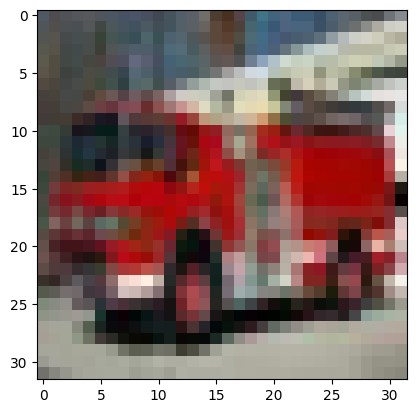

truck


In [3]:
# To check that we got correct dataset
def imshow(img):
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.show()

c=23
imshow(test_dataset[c][0])
print(classes[test_dataset[c][1]])


In [4]:
######################################################################
## This architecture is taken from the official tutorial of PyTorch ##
######################################################################
################################
### Build the Neural Network ###
################################
import torch.nn as nn # nn means Neural Network.
class CIFAR10_classification_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
        nn.Conv2d(3, 6, 5),# input image is 32*32. Filter size is 5. No padding. Then the output image is 28*28.
        nn.ReLU(),
        nn.MaxPool2d(2, 2),#28*28 shrinks to 14*14.
        nn.Conv2d(6, 16, 5),# input image is 14*14. Filter size is 5. No padding. Then the output image is 10*10.
        nn.ReLU(),
        nn.MaxPool2d(2, 2),#10*10 shrinks to 5*5.
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120),#5*5 pictures, 16 channels.
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10),
        nn.LogSoftmax(dim=1),
        )
    # "forward" is forward propagation.
    # It just inputs x to NN and get output.
    def forward(self, x: torch.Tensor):
        # rgb, 32*32 pixels
        x = x.view(-1, 3, 32, 32)
        x = self.model(x)
        return x

In [5]:
lr = 0.002
nepoch = 20
################################
### Set a model for training ###
################################
model = CIFAR10_classification_Model()
# NLL is used as loss function
# NLL = Negative Log LikeLihood
criterion = nn.NLLLoss()
# Adam is used as optimizer
# Adam = ADAptive Moment estimation
# We do not have to write gradient descent by ourselves!
optimizer = torch.optim.Adam(model.parameters(), lr)
##################################
### Optimization of parameters ###
##################################
for epoch in range(nepoch):
    total_loss = 0
    for images, labels in train_loader:
        # initialize the gradient with zero at each back propagation
        #   (otherwise wrong value can be obtained)
        optimizer.zero_grad()
        outputs = model(images)
        ## output = LogSoftmax, criterion = NLL, "labels" for second argument
        ##  -> cross entropy loss is calculated as cost function.
        loss = criterion(outputs, labels)
        #loss.backward() computes gradients
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    # average loss during the epoch
    print('Epoch:', epoch + 1, 'Loss:', total_loss/len(train_loader))
###############################
### Test of the performance ###
###############################
correct = 0
total = 0
# "model.eval" is the evaluation mode. Not important for this model.
# When we use drop out, batch normalization, etc,
#   then training mode and evaluation mode are different.
model.eval()
with torch.no_grad():
# Gradient is not calculated (not needed for model evaluation)
# We could also use "with torch.set_grad_enabled(False):"
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()


print("Success rate:",correct,"/",total)

Epoch: 1 Loss: 1.6600280193328858
Epoch: 2 Loss: 1.4104501849746705
Epoch: 3 Loss: 1.3223233119392395
Epoch: 4 Loss: 1.2634741691970826
Epoch: 5 Loss: 1.219570865650177
Epoch: 6 Loss: 1.1893972459983826
Epoch: 7 Loss: 1.156423146381378
Epoch: 8 Loss: 1.129917728357315
Epoch: 9 Loss: 1.107601094789505
Epoch: 10 Loss: 1.0895686025047302
Epoch: 11 Loss: 1.072368466873169
Epoch: 12 Loss: 1.0583444358158112
Epoch: 13 Loss: 1.0418016918945312
Epoch: 14 Loss: 1.024055926809311
Epoch: 15 Loss: 1.009883399248123
Epoch: 16 Loss: 0.9964579667186737
Epoch: 17 Loss: 0.9839024863243103
Epoch: 18 Loss: 0.968140604019165
Epoch: 19 Loss: 0.9621851774311065
Epoch: 20 Loss: 0.9520491175889969
Success rate: 5685 / 10000


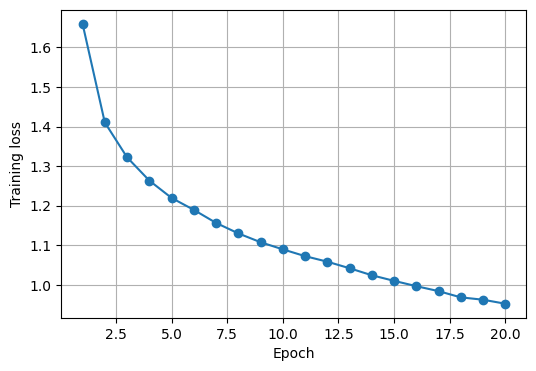

In [6]:
import matplotlib.pyplot as plt

epochs = list(range(1, 21))

train_losses = [
    1.6600280193328858,
    1.4104501849746705,
    1.3223233119392395,
    1.2634741691970826,
    1.219570865650177,
    1.1893972459983826,
    1.156423146381378,
    1.129917728357315,
    1.107601094789505,
    1.0895686025047302,
    1.072368466873169,
    1.0583444358158112,
    1.0418016918945312,
    1.024055926809311,
    1.009883399248123,
    0.9964579667186737,
    0.9839024863243103,
    0.968140604019165,
    0.9621851774311065,
    0.9520491175889969
]

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.grid(True)
plt.savefig("training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# to avoid re-treining every single time, we can save it

# torch.save(model.state_dict(), "cifar10_cnn.pth")

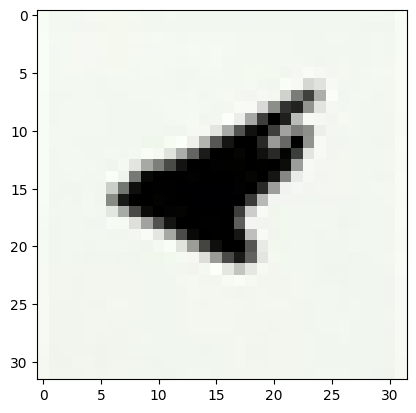

plane
****** output (LogSoftmax) ********
tensor([[ -0.6797, -17.2474,  -0.7071, -10.2108, -10.2341, -13.0110, -13.4018,
         -13.2080,  -9.2669, -17.3965]], grad_fn=<LogSoftmaxBackward0>)
****** prediction ********
plane
****** label ********
plane
****** Success or not ********
success!


In [8]:
c=21
# Plot image
imshow(test_dataset[c][0])
print(classes[test_dataset[c][1]])
# output
print('****** output (LogSoftmax) ********')
print(model(test_dataset[c][0]))
# prediction based on the largest probability
print('****** prediction ********')
prediction = torch.argmax(model(test_dataset[c][0]))
print(classes[prediction.item()])
# label
print('****** label ********')
print(classes[test_dataset[c][1]])
print('****** Success or not ********')
if prediction == test_dataset[c][1]:
  print('success!')
else:
  print('oops...')

In [9]:
def fgsm_attack(image, epsilon, image_gradient):
    # sign of gradient
    sign_gradient = image_gradient.sign()

    # add perturbation
    adversarial_image = image + epsilon * sign_gradient

    # keep valid pixel range [0, 1]
    adversarial_image = torch.clamp(adversarial_image, 0, 1)

    return adversarial_image

In [10]:
def imshow_small(img, title=None):
    img = img.detach().cpu()
    
    if img.dim() == 4:
        img = img.squeeze(0)
    
    img = np.transpose(img.numpy(), (1, 2, 0))
    
    plt.figure(figsize=(2, 2))
    plt.imshow(img, interpolation="nearest")
    plt.axis("off")
    
    if title is not None:
        plt.title(title)
    
    plt.show()

In [11]:
epsilon = 0.01

adversarial_examples = []
used_true_classes = set()

model.eval()

for i in range(len(test_dataset)):
    image, label = test_dataset[i]

    # Skip this class if we already have one successful example from it
    if label in used_true_classes:
        continue

    # Add batch dimension: [3, 32, 32] -> [1, 3, 32, 32]
    image = image.unsqueeze(0)
    label_tensor = torch.tensor([label])

    # We need gradient with respect to the input image
    image.requires_grad = True

    # Clean prediction
    output = model(image)
    original_prediction = torch.argmax(output, dim=1)

    # Use only images correctly classified before the attack
    if original_prediction.item() != label:
        continue

    # Compute loss with respect to the true label
    loss = criterion(output, label_tensor)

    # Backpropagate to get gradient with respect to the image
    model.zero_grad()
    loss.backward()

    image_gradient = image.grad.data

    # Create adversarial image using FGSM
    adversarial_image = fgsm_attack(image, epsilon, image_gradient)

    # Prediction on adversarial image
    adversarial_output = model(adversarial_image)
    adversarial_prediction = torch.argmax(adversarial_output, dim=1)

    # Keep only successful attacks
    if adversarial_prediction.item() != label:
        # Since the model outputs LogSoftmax values,
        # torch.exp(...) converts log-probabilities into probabilities.
        clean_probs = torch.exp(output)
        adversarial_probs = torch.exp(adversarial_output)

        clean_confidence = clean_probs[0, original_prediction.item()].item()
        adversarial_confidence = adversarial_probs[0, adversarial_prediction.item()].item()

        adversarial_examples.append({
            "index": i,
            "original_image": image.detach(),
            "adversarial_image": adversarial_image.detach(),
            "true_label": label,
            "original_prediction": original_prediction.item(),
            "adversarial_prediction": adversarial_prediction.item(),
            "clean_confidence": clean_confidence,
            "adversarial_confidence": adversarial_confidence
        })

        used_true_classes.add(label)

    if len(adversarial_examples) == 5:
        break

print(f"Found {len(adversarial_examples)} adversarial examples from different classes.")

Found 5 adversarial examples from different classes.


Example 1
Index: 1
True label: ship
Original prediction: ship (0.612)
Adversarial prediction: car (0.878)


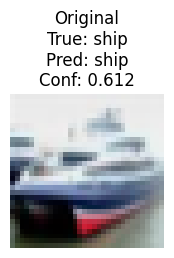

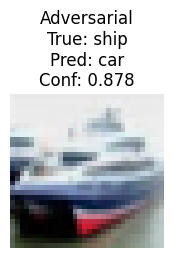

--------------------------------------------------
Example 2
Index: 3
True label: plane
Original prediction: plane (0.817)
Adversarial prediction: ship (0.407)


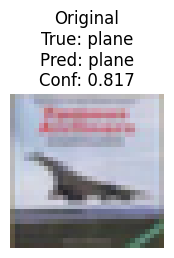

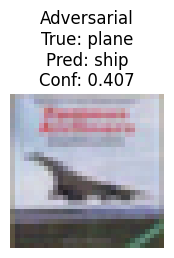

--------------------------------------------------
Example 3
Index: 5
True label: frog
Original prediction: frog (0.830)
Adversarial prediction: bird (0.336)


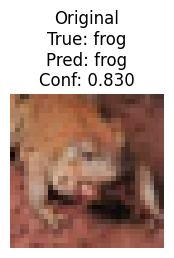

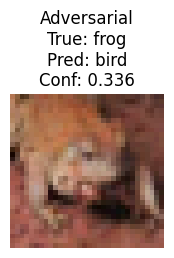

--------------------------------------------------
Example 4
Index: 8
True label: cat
Original prediction: cat (0.369)
Adversarial prediction: deer (0.836)


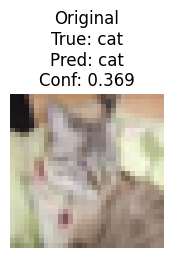

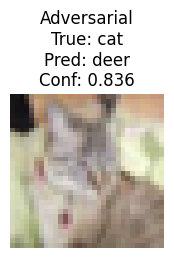

--------------------------------------------------
Example 5
Index: 12
True label: dog
Original prediction: dog (0.508)
Adversarial prediction: frog (0.722)


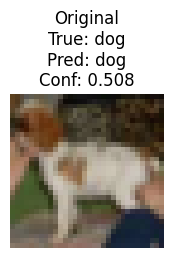

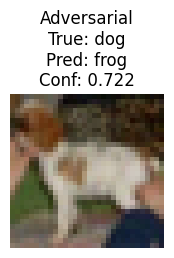

--------------------------------------------------


In [12]:
for k, example in enumerate(adversarial_examples):
    print(f"Example {k + 1}")
    print("Index:", example["index"])
    print("True label:", classes[example["true_label"]])
    print(
        "Original prediction:",
        classes[example["original_prediction"]],
        f"({example['clean_confidence']:.3f})"
    )
    print(
        "Adversarial prediction:",
        classes[example["adversarial_prediction"]],
        f"({example['adversarial_confidence']:.3f})"
    )

    imshow_small(
        example["original_image"],
        title=(
            f"Original\n"
            f"True: {classes[example['true_label']]}\n"
            f"Pred: {classes[example['original_prediction']]}\n"
            f"Conf: {example['clean_confidence']:.3f}"
        )
    )

    imshow_small(
        example["adversarial_image"],
        title=(
            f"Adversarial\n"
            f"True: {classes[example['true_label']]}\n"
            f"Pred: {classes[example['adversarial_prediction']]}\n"
            f"Conf: {example['adversarial_confidence']:.3f}"
        )
    )

    print("-" * 50)

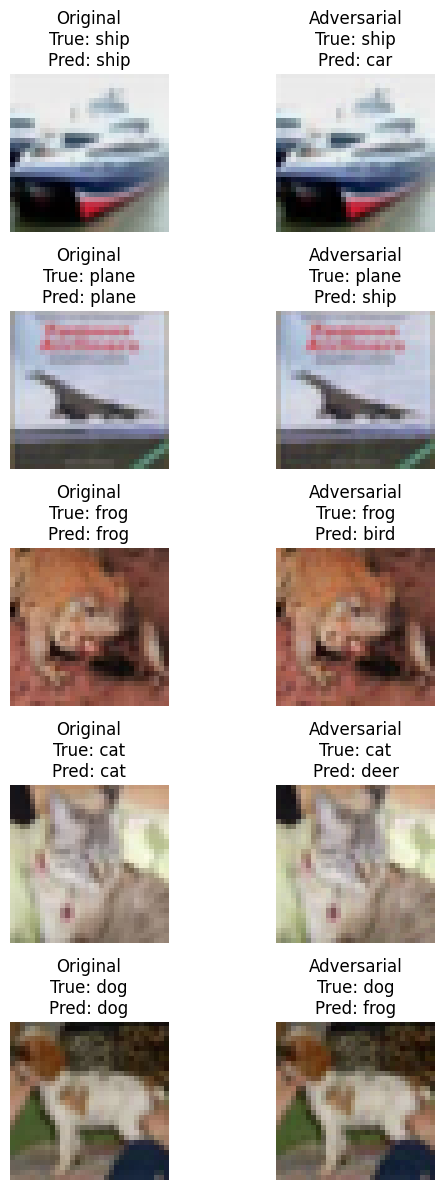

In [13]:
fig, axes = plt.subplots(len(adversarial_examples), 2, figsize=(6, 12))

for row, example in enumerate(adversarial_examples):
    original = example["original_image"].squeeze(0).detach().cpu()
    adversarial = example["adversarial_image"].squeeze(0).detach().cpu()

    original = np.transpose(original.numpy(), (1, 2, 0))
    adversarial = np.transpose(adversarial.numpy(), (1, 2, 0))

    true_label = classes[example["true_label"]]
    original_pred = classes[example["original_prediction"]]
    adversarial_pred = classes[example["adversarial_prediction"]]

    axes[row, 0].imshow(original, interpolation="nearest")
    axes[row, 0].set_title(f"Original\nTrue: {true_label}\nPred: {original_pred}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(adversarial, interpolation="nearest")
    axes[row, 1].set_title(f"Adversarial\nTrue: {true_label}\nPred: {adversarial_pred}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig("adversarial_examples.png", dpi=300, bbox_inches="tight")
plt.show()

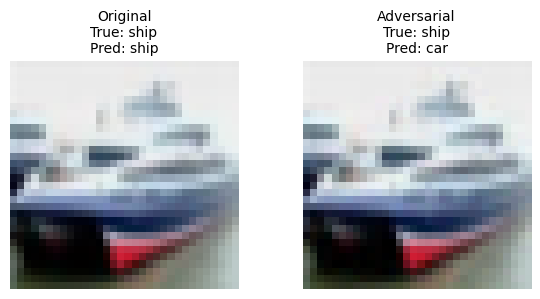

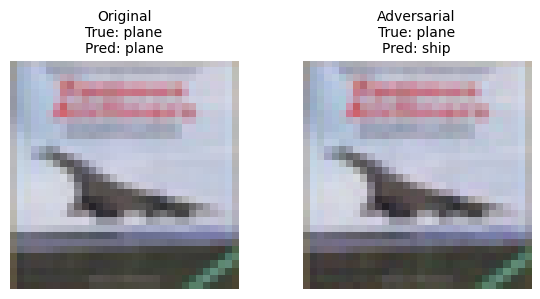

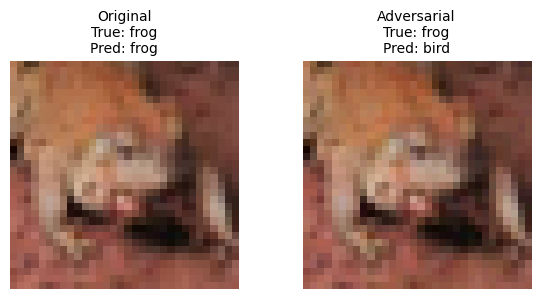

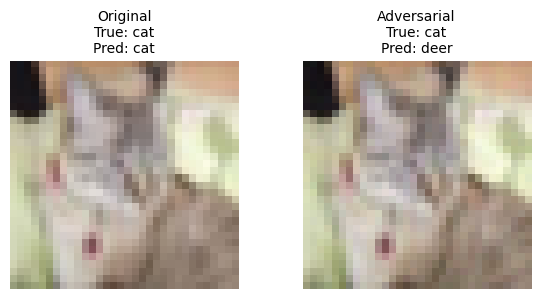

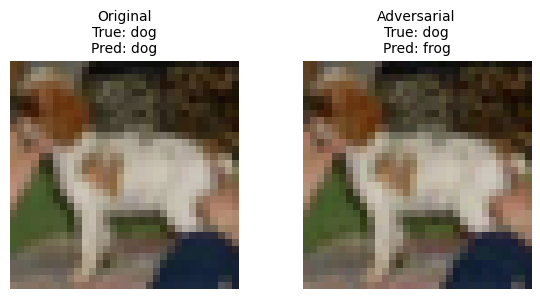

In [14]:
for i, example in enumerate(adversarial_examples, start=1):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    original = example["original_image"].squeeze(0).detach().cpu()
    adversarial = example["adversarial_image"].squeeze(0).detach().cpu()

    original = np.transpose(original.numpy(), (1, 2, 0))
    adversarial = np.transpose(adversarial.numpy(), (1, 2, 0))

    true_label = classes[example["true_label"]]
    original_pred = classes[example["original_prediction"]]
    adversarial_pred = classes[example["adversarial_prediction"]]

    axes[0].imshow(original, interpolation="nearest")
    axes[0].set_title(f"Original\nTrue: {true_label}\nPred: {original_pred}", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(adversarial, interpolation="nearest")
    axes[1].set_title(f"Adversarial\nTrue: {true_label}\nPred: {adversarial_pred}", fontsize=10)
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(f"adv_example_{i}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [15]:
def evaluate_fgsm_accuracy(model, data_loader, criterion, epsilon):
    model.eval()

    correct = 0
    total = 0

    for images, labels in data_loader:
        # We need gradients with respect to the input images
        images.requires_grad = True

        # Forward pass on clean images
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagate to get gradients with respect to images
        model.zero_grad()
        loss.backward()

        image_gradients = images.grad.data

        # FGSM attack
        adversarial_images = images + epsilon * image_gradients.sign()
        adversarial_images = torch.clamp(adversarial_images, 0, 1)

        # Evaluate model on adversarial images
        adversarial_outputs = model(adversarial_images)
        _, predicted = adversarial_outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


epsilons = [0.0, 0.001, 0.003, 0.005, 0.01, 0.03]

fgsm_accuracies = []

for eps in epsilons:
    acc = evaluate_fgsm_accuracy(
        model,
        test_loader,
        criterion,
        eps
    )
    fgsm_accuracies.append(acc)
    print(f"Epsilon: {eps:.3f}, FGSM accuracy: {acc:.2f}%")

Epsilon: 0.000, FGSM accuracy: 56.85%
Epsilon: 0.001, FGSM accuracy: 50.21%
Epsilon: 0.003, FGSM accuracy: 39.28%
Epsilon: 0.005, FGSM accuracy: 31.12%
Epsilon: 0.010, FGSM accuracy: 19.65%
Epsilon: 0.030, FGSM accuracy: 5.59%


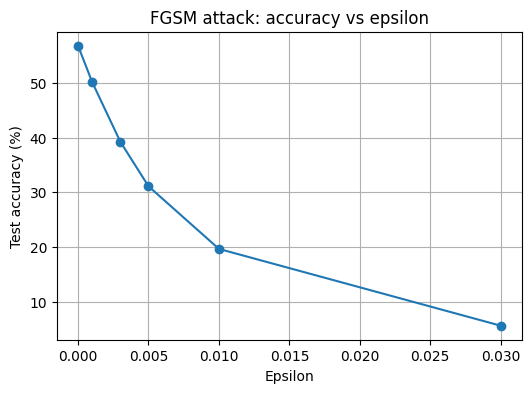

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(epsilons, fgsm_accuracies, marker="o")
plt.xlabel("Epsilon")
plt.ylabel("Test accuracy (%)")
plt.title("FGSM attack: accuracy vs epsilon")
plt.grid(True)
plt.savefig("accuracy_vs_epsilon.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
def evaluate_random_noise_accuracy(model, data_loader, epsilon):
    model.eval()

    correct = 0
    total = 0

    for images, labels in data_loader:
        # Create random uniform noise in the range [-epsilon, epsilon]
        noise = torch.empty_like(images).uniform_(-epsilon, epsilon)

        # Add noise and keep pixel values in valid range [0, 1]
        noisy_images = images + noise
        noisy_images = torch.clamp(noisy_images, 0, 1)

        # Evaluate model on noisy images
        outputs = model(noisy_images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return 100 * correct / total

In [18]:
random_noise_accuracies = []

for eps in epsilons:
    acc = evaluate_random_noise_accuracy(model, test_loader, eps)
    random_noise_accuracies.append(acc)
    print(f"Epsilon: {eps:.3f}, Random noise accuracy: {acc:.2f}%")

Epsilon: 0.000, Random noise accuracy: 56.85%
Epsilon: 0.001, Random noise accuracy: 56.84%
Epsilon: 0.003, Random noise accuracy: 56.91%
Epsilon: 0.005, Random noise accuracy: 56.82%
Epsilon: 0.010, Random noise accuracy: 56.88%
Epsilon: 0.030, Random noise accuracy: 56.91%


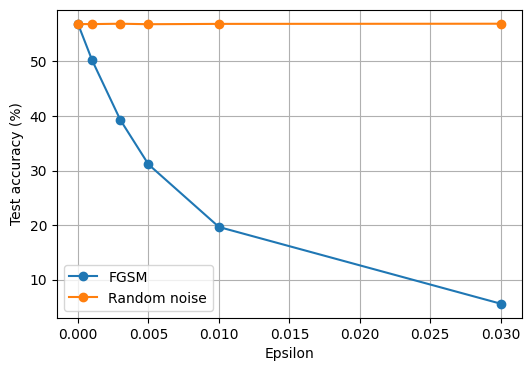

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(epsilons, fgsm_accuracies, marker="o", label="FGSM")
plt.plot(epsilons, random_noise_accuracies, marker="o", label="Random noise")
plt.xlabel("Epsilon")
plt.ylabel("Test accuracy (%)")
# plt.title("FGSM vs random noise")
plt.legend()
plt.grid(True)
plt.savefig("fgsm_vs_random_noise.png", dpi=300, bbox_inches="tight")
plt.show()

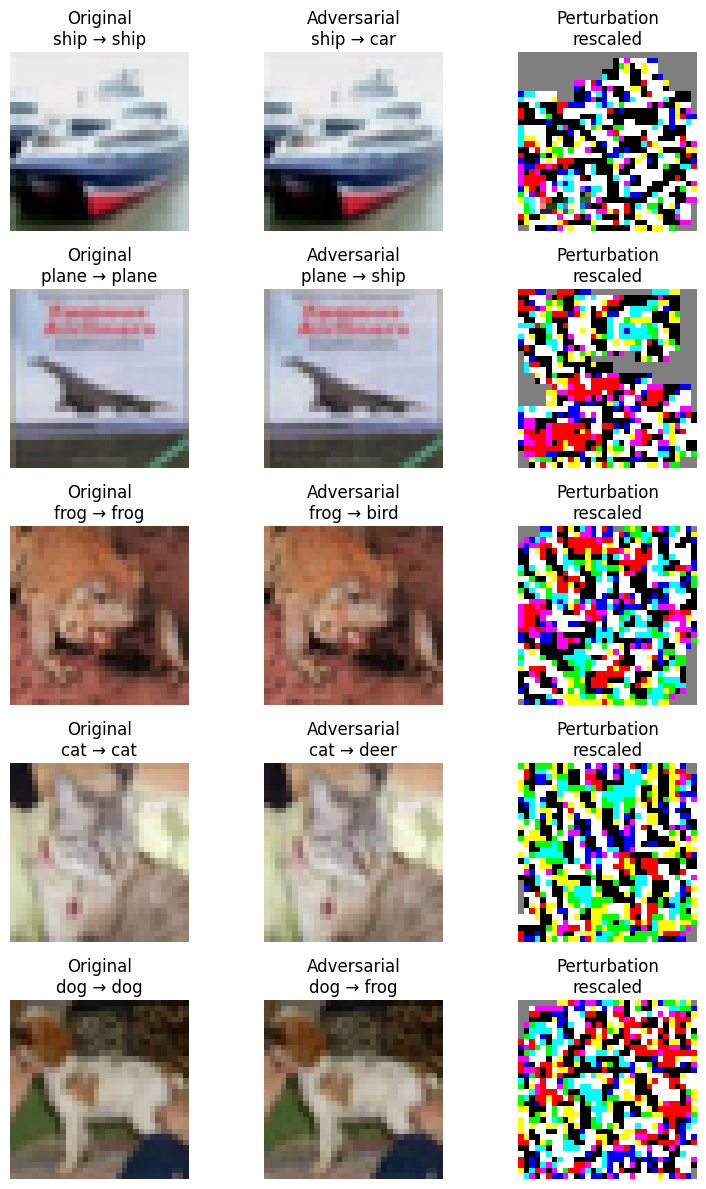

In [20]:
fig, axes = plt.subplots(len(adversarial_examples), 3, figsize=(8, 12))

for row, example in enumerate(adversarial_examples):
    original = example["original_image"].squeeze(0).detach().cpu()
    adversarial = example["adversarial_image"].squeeze(0).detach().cpu()

    perturbation = adversarial - original

    # Rescale perturbation for visualisation only
    perturbation_vis = perturbation - perturbation.min()
    perturbation_vis = perturbation_vis / perturbation_vis.max()

    original_np = np.transpose(original.numpy(), (1, 2, 0))
    adversarial_np = np.transpose(adversarial.numpy(), (1, 2, 0))
    perturbation_np = np.transpose(perturbation_vis.numpy(), (1, 2, 0))

    true_label = classes[example["true_label"]]
    original_pred = classes[example["original_prediction"]]
    adversarial_pred = classes[example["adversarial_prediction"]]

    axes[row, 0].imshow(original_np, interpolation="nearest")
    axes[row, 0].set_title(f"Original\n{true_label} → {original_pred}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(adversarial_np, interpolation="nearest")
    axes[row, 1].set_title(f"Adversarial\n{true_label} → {adversarial_pred}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(perturbation_np, interpolation="nearest")
    axes[row, 2].set_title("Perturbation\nrescaled")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("adversarial_examples_with_perturbation.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
def evaluate_attack_success_rate(model, data_loader, criterion, epsilon):
    model.eval()

    originally_correct = 0
    successful_attacks = 0

    for images, labels in data_loader:
        images.requires_grad = True

        # Clean predictions
        outputs = model(images)
        _, clean_predicted = outputs.max(1)

        # Only consider images that were originally classified correctly
        correct_mask = clean_predicted.eq(labels)

        if correct_mask.sum().item() == 0:
            continue

        originally_correct += correct_mask.sum().item()

        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        image_gradients = images.grad.data

        adversarial_images = images + epsilon * image_gradients.sign()
        adversarial_images = torch.clamp(adversarial_images, 0, 1)

        adversarial_outputs = model(adversarial_images)
        _, adversarial_predicted = adversarial_outputs.max(1)

        # Successful attack = originally correct, but adversarially wrong
        successful_mask = correct_mask & (~adversarial_predicted.eq(labels))
        successful_attacks += successful_mask.sum().item()

    success_rate = 100 * successful_attacks / originally_correct
    return originally_correct, successful_attacks, success_rate

In [26]:
epsilons = [0.001, 0.003, 0.005, 0.01, 0.03]

attack_success_rates = []

for eps in epsilons:
    originally_correct, successful_attacks, success_rate = evaluate_attack_success_rate(
        model,
        test_loader,
        criterion,
        eps
    )
    attack_success_rates.append(success_rate)

    print(
        f"Epsilon: {eps:.3f}, "
        f"Originally correct: {originally_correct}, "
        f"Successful attacks: {successful_attacks}, "
        f"Attack success rate: {success_rate:.2f}%"
    )

Epsilon: 0.001, Originally correct: 5685, Successful attacks: 665, Attack success rate: 11.70%
Epsilon: 0.003, Originally correct: 5685, Successful attacks: 1759, Attack success rate: 30.94%
Epsilon: 0.005, Originally correct: 5685, Successful attacks: 2577, Attack success rate: 45.33%
Epsilon: 0.010, Originally correct: 5685, Successful attacks: 3725, Attack success rate: 65.52%
Epsilon: 0.030, Originally correct: 5685, Successful attacks: 5131, Attack success rate: 90.26%
